In [13]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [14]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df.drop("Cabin", axis=1, inplace=True)

df["Sex"] = LabelEncoder().fit_transform(df["Sex"])
df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])

X = df.drop(["PassengerId","Name","Ticket","Survived"], axis=1)
y = df["Survived"]

In [16]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (712, 7)
Testing Shape : (179, 7)


In [18]:
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [19]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train,y_train)

lr_preds = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test,lr_preds)

print("Logistic Regression Accuracy :",round(lr_accuracy*100,2),"%")

Logistic Regression Accuracy : 79.89 %


In [20]:
lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train,y_train)

lda_preds = lda_model.predict(X_test)

lda_accuracy = accuracy_score(y_test,lda_preds)

print("LDA Accuracy :",round(lda_accuracy*100,2),"%")

LDA Accuracy : 79.33 %


In [21]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train,y_train)

knn_preds = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test,knn_preds)

print("KNN Accuracy :",round(knn_accuracy*100,2),"%")

KNN Accuracy : 81.56 %


In [22]:
nb_model = GaussianNB()

nb_model.fit(X_train,y_train)

nb_preds = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test,nb_preds)

print("Naive Bayes Accuracy :",round(nb_accuracy*100,2),"%")

Naive Bayes Accuracy : 78.21 %


In [23]:
svm_model = SVC(kernel="linear",probability=True,random_state=42)

svm_model.fit(X_train,y_train)

svm_preds = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test,svm_preds)

print("Linear SVM Accuracy :",round(svm_accuracy*100,2),"%")

Linear SVM Accuracy : 77.65 %


In [24]:
comparison = pd.DataFrame({

    "Classifier":[
        "Logistic Regression",
        "Linear Discriminant Analysis",
        "K-Nearest Neighbors",
        "Gaussian Naive Bayes",
        "Linear SVM"
    ],

    "Accuracy (%)":[
        round(lr_accuracy*100,2),
        round(lda_accuracy*100,2),
        round(knn_accuracy*100,2),
        round(nb_accuracy*100,2),
        round(svm_accuracy*100,2)
    ]
})

comparison

,Classifier,Accuracy (%)
0,Logistic Regression,79.89
1,Linear Discriminant Analysis,79.33
2,K-Nearest Neighbors,81.56
3,Gaussian Naive Bayes,78.21
4,Linear SVM,77.65


In [25]:
print(comparison.to_string(index=False))

                  Classifier  Accuracy (%)
         Logistic Regression         79.89
Linear Discriminant Analysis         79.33
         K-Nearest Neighbors         81.56
        Gaussian Naive Bayes         78.21
                  Linear SVM         77.65


In [26]:
print(classification_report(
    y_test,
    lr_preds,
    target_names=["Not Survived","Survived"]
))

              precision    recall  f1-score   support

Not Survived       0.81      0.88      0.84       110
    Survived       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



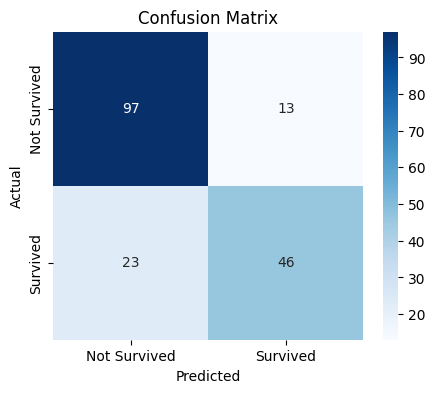

In [27]:
cm = confusion_matrix(y_test,lr_preds)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Not Survived","Survived"],
    yticklabels=["Not Survived","Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

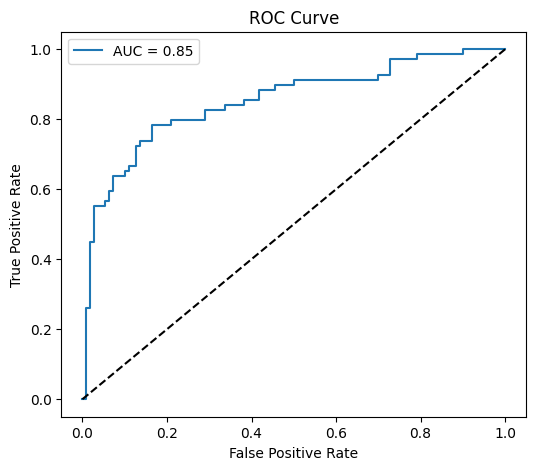

In [28]:
y_score = lr_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,y_score)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="AUC = %.2f"%roc_auc)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean Accuracy: {np.mean(cv_scores)*100:.2f}%")
print(f"Standard Deviation: {np.std(cv_scores)*100:.2f}%")

Cross Validation Scores
Fold 1: 0.7902
Fold 2: 0.7622
Fold 3: 0.8028
Fold 4: 0.8169
Fold 5: 0.8099

Mean Accuracy: 79.64%
Standard Deviation: 1.92%
